# Multi-modal RAG System

It is worth considering how to utilize images in RAG Systems:

![](https://i.imgur.com/wcCDT38.gif)

The idea:

* Use a multimodal LLM (such as [GPT-4o](https://openai.com/index/hello-gpt-4o/), [LLaVA](https://github.com/haotian-liu/LLaVA), or [FUYU-8b](https://www.adept.ai/blog/fuyu-8b)) to produce text summaries from images and tables
* Embed and retrieve image, table and text summaries with a reference to the raw images and tables for given queries
* Pass raw images, tables and text chunks to a multimodal LLM for answer synthesis   

---


### Stack

* [Unstructured](https://unstructured.io/) to parse images, text, and tables from documents (PDFs).
* [Multi-vector retriever](https://python.langchain.com/api_reference/langchain/retrievers/langchain.retrievers.multi_vector.MultiVectorRetriever.html#multivectorretriever) with [Chroma](https://www.trychroma.com/) and Redis to store raw text and images along with their summaries for retrieval.
* GPT-4o for both image summarization (for retrieval) as well as final answer synthesis from join review of images and texts (or tables).


___Created By: [Sebastian Laverde](https://www.linkedin.com/in/sebastian-laverde-alfonso/)___

## Environment and Logging

In [1]:
import logging

from colorlog import ColoredFormatter


formatter = ColoredFormatter(
    "%(log_color)s%(asctime)s - %(levelname)-8s:%(reset)s %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    log_colors={
        'DEBUG':    'cyan',
        'INFO':     'green',
        'WARNING':  'yellow',
        'ERROR':    'red',
        'CRITICAL': 'bold_red',
    }
)

handler = logging.StreamHandler()
handler.setFormatter(formatter)

logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [handler]

In [2]:
from dotenv import load_dotenv

# Load env vars (api keys inside .env)
load_dotenv()

True

## Data Loading & Processing

Use Unstructured.io for partitioning the PDF. Use GPT-4o the generate elements (text|table|image) summaries.

### Partition PDF

In [3]:
import logging
import shutil

from langchain_community.document_loaders import UnstructuredPDFLoader
from pathlib import Path
from tqdm import tqdm


# Silence pdfminer noise
logging.getLogger('pdfminer').setLevel(logging.ERROR)


def multimodal_unstructured_loader(doc_path):
    """
    Run the UnstructuredPDFLoader twice to first extract all tables and then load all text and chunk it.
    Reason for this is in the latest version of unstructured, you lose the table elements if you chunk directly. 
    Refer to: https://github.com/Unstructured-IO/unstructured/issues/3827 for more details.
    """
    
    # Extract tables
    loader = UnstructuredPDFLoader(file_path=doc_path,
                                   strategy='hi_res',
                                   extract_images_in_pdf=True,
                                   infer_table_structure=True,
                                   mode='elements')
    data = loader.load()
    tables = [doc for doc in data if doc.metadata['category'] == 'Table']

    # Chunk text and extract text content
    loader = UnstructuredPDFLoader(file_path=doc_path,
                                   strategy='hi_res',
                                   extract_images_in_pdf=True,
                                   infer_table_structure=True,
                                   chunking_strategy="by_title", # section-based chunking
                                   max_characters=4000, # max size of chunks
                                   new_after_n_chars=3000, # preferred size of chunks
                                   combine_text_under_n_chars=2000, # smaller chunks < 2000 chars will be combined into a larger chunk
                                   mode='elements')
    texts = loader.load()

    # Rename all figures files in the folder by adding the source pdf filename root as prefix
    prefix = Path(doc_path).stem
    default_imgs_folder = Path('./figures')
    destination_folder = Path('./images')
    destination_folder.mkdir(exist_ok=True, parents=True)

    for jpg_file in default_imgs_folder.glob('*.jpg'):
        new_name = f"{prefix}_{jpg_file.name}"
        new_path = destination_folder / new_name
        jpg_file.rename(new_path)
        logging.debug(f"Moved & Renamed: {default_imgs_folder} → {new_path.name}")
        
    if default_imgs_folder.exists() and default_imgs_folder.is_dir():
        shutil.rmtree(default_imgs_folder)
        logging.debug(f"Deleted folder: {default_imgs_folder}")
        
    return texts + tables

In [4]:
# Partition PDF tables, text, and images
DATA_PATH = Path('./data')

partitioned_collection = [multimodal_unstructured_loader(pdf_path) for pdf_path in tqdm(DATA_PATH.glob('*.pdf'))]

0it [00:00, ?it/s]2025-06-05 12:42:34 - INFO    : pikepdf C++ to Python logger bridge initialized
2025-06-05 12:42:36 - INFO    : Reading PDF for file: data\1706.03762v7.pdf ...
2025-06-05 12:42:46 - INFO    : Loading the Table agent ...
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
2025-06-05 12:42:47 - INFO    : Loading the table structure model ...
2025-06-05 12:42:47 - INFO    : Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
2025-06-05 12:42:47 - INFO    : [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2025-06-05 12:42:47 - INFO    : Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
2025-06-05 12:43:05 - INFO    : Reading PDF for file: data\1706.03762v7.pdf ...
1it [01:01, 61.16s/it]2025-06-05 12:43:32 - INFO    : Reading PDF

### Separate Text | Images | Tables

In [5]:
import htmltabletomd


def preprocess_document_elements(elements):
    """
    Separates a list of document elements into text and table components.
    This function processes a collection of document elements, converting any HTML-based
    tables to Markdown format and categorizing elements into two groups: Texts and Tables.
    For Tables, the element.page_content is overwritten with the markdown version of the hmtl.
    """
    
    texts, tables = [], []
    for element in elements:
        if element.metadata['category'] == 'Table':
            # Convert HTML Tables to Markdown
            element.page_content = htmltabletomd.convert_table(element.metadata['text_as_html'])
            tables.append(element)
        elif element.metadata['category'] == 'CompositeElement':
            texts.append(element)
    return texts, tables

In [6]:
# Separate Tables from other elements and pass to markdown
proc_partitioned_collection = [preprocess_document_elements(partitioned_doc) for partitioned_doc in tqdm(partitioned_collection)]
narrative_content, tabular_content = [], []

for texts, tables in proc_partitioned_collection:
    narrative_content.extend(texts)
    tabular_content.extend(tables)

logging.info(f"Number of narrative content chunks: {len(narrative_content)}")
logging.info(f"Number of tabular content chunks: {len(tabular_content)}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 43.01it/s]
2025-06-05 12:50:11 - INFO    : Number of narrative content chunks: 132
2025-06-05 12:50:11 - INFO    : Number of tabular content chunks: 37


### Text and Tables Summaries

In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI


chatgpt = ChatOpenAI(model_name='gpt-4o', temperature=0, max_retries=5)

prompt_text = """
You are an assistant tasked with summarizing tables and text particularly for semantic retrieval.
These summaries will be embedded and used to retrieve the raw text or table elements
Give a detailed summary of the table or text below that is well optimized for retrieval.
For any tables also add in a one line description of what the table is about besides the summary.
Do not add redundant words like Summary.
Just output the actual summary content.

Table or text chunk:
{element}
"""
prompt = ChatPromptTemplate.from_template(prompt_text)

summarize_chain = (
                    {"element": RunnablePassthrough()}
                      |
                    prompt
                      |
                    chatgpt
                      |
                    StrOutputParser()
)

# Initialize empty summaries
text_summaries = []
table_summaries = []

text_docs = [doc.page_content for doc in narrative_content]
table_docs = [table.page_content for table in tabular_content]

text_summaries = summarize_chain.batch(text_docs, {"max_concurrency": 2})
table_summaries = summarize_chain.batch(table_docs, {"max_concurrency": 2})

len(text_summaries), len(table_summaries)

2025-06-05 12:50:17 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:17 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:20 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:21 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:25 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:25 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:29 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:30 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 12:50:33 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 

(132, 37)

In [8]:
text_docs[0]

'3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0\n\n7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗ Google Brain noam@google.com\n\nNiki Parmar∗ Google Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attentio

In [9]:
text_summaries[0]

'This text is an abstract from the paper "Attention Is All You Need," presented at the 31st Conference on Neural Information Processing Systems (NIPS 2017). The paper introduces the Transformer, a novel network architecture for sequence transduction tasks that relies solely on attention mechanisms, eliminating the need for recurrent or convolutional neural networks. The Transformer demonstrates superior performance in machine translation tasks, achieving a BLEU score of 28.4 on the WMT 2014 English-to-German task and 41.8 on the English-to-French task, with significantly reduced training time. The model also generalizes well to other tasks, such as English constituency parsing. The authors, affiliated with Google Brain, Google Research, and the University of Toronto, contributed equally to the work, with specific roles in proposing, designing, implementing, and evaluating the Transformer and its variants. The paper emphasizes the model\'s efficiency, parallelizability, and state-of-the

In [10]:
table_docs[1]

"| Model | EN-DE | EN-FR | Training EN-DE | EN-FR |\n| :--- | :--- | :--- | :--- | :--- |\n| ByteNet [18] 23.75 |\n| Deep-Att + PosUnk |  | 39.2 |  | 1.0 - 107° |\n| GNMT + RL 8] | 24.6 | 39.92 | 2.3-10!9 | 1.4-1070 |\n| ConvS28S [9] | 25.16 | 40.46 | 9.6-10'% | 1.5-1070 |\n| MoE | 26.03 | 40.56 | 2.0-10'9 | 1.2. 1079 |\n| Deep-Att + PosUnk Ensemble |  | 40.4 |  | 8.0 - 107° |\n| GNMT + RL Ensemble (33 | 26.30 | 41.16 | 1.8-1079 | 1.1- 1074 |\n| ConvS2S Ensemble [9] | 26.36 | 41.29 | 7.7-10'9 | 1.2.10?! |\n| Transformer (base model) | 27.3 | 38.1 | 3.3- | 1018 |\n| Transformer (big) | 28.4 | 41.8 | 2.3. | 1019 |\n"

In [11]:
table_summaries[1]

'This table compares various machine translation models based on their performance in translating from English to German (EN-DE) and English to French (EN-FR), as well as their training efficiency. The models include ByteNet, Deep-Att + PosUnk, GNMT + RL, ConvS2S, MoE, and Transformer, with both base and big versions. Performance is measured in terms of translation quality scores, with the Transformer (big) model achieving the highest scores of 28.4 for EN-DE and 41.8 for EN-FR. Training efficiency is indicated by numerical values, with lower numbers suggesting more efficient training. Ensemble versions of some models, such as Deep-Att + PosUnk and GNMT + RL, generally show improved performance over their non-ensemble counterparts.'

### Image summaries

In [16]:
import base64

from langchain_core.messages import HumanMessage


def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def image_summarize(img_base64, prompt):
    """Make image summary"""

    msg = chatgpt.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content


def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    img_base64_list = []
    image_summaries = []

    prompt = """You are an assistant tasked with summarizing images for retrieval.
                Remember these images could potentially contain graphs, charts or tables also.
                These summaries will be embedded and used to retrieve the raw image for question answering.
                Give a detailed summary of the image that is well optimized for retrieval.
                Do not add additional words like Summary, This image represents, etc.
             """

    # Summarize images
    for img_path in sorted(Path(path).glob('*.jpg')):
        image_path_str = str(img_path)
        if image_path_str.endswith(".jpg"):
            base64_image = encode_image(image_path_str)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries

In [17]:
# Image summaries
imgs_base64, image_summaries = generate_img_summaries("./images")
len(imgs_base64), len(image_summaries)

2025-06-05 13:07:16 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:20 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:26 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:30 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:34 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:37 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:40 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:44 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-06-05 13:07:49 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 

(95, 95)

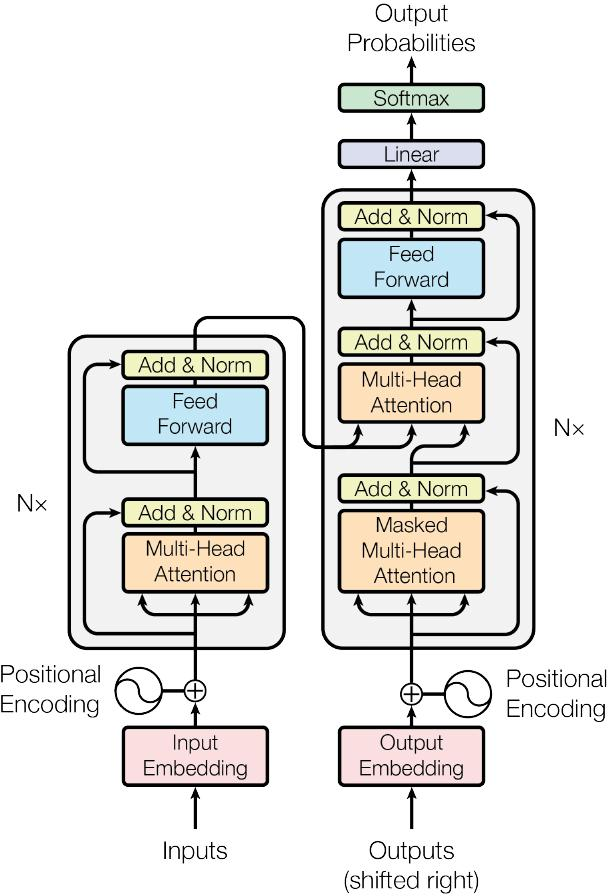

In [27]:
from IPython.display import Image

display(Image('./images/1706.03762v7_figure-3-1.jpg'))

In [28]:
image_summaries[4]  # './images/1706.03762v7_figure-3-1.jpg'

'Diagram of a transformer model architecture featuring two main components: the encoder and decoder. The encoder consists of layers with multi-head attention and feed-forward networks, each followed by add and norm operations. Positional encoding is applied to input embeddings. The decoder includes masked multi-head attention, multi-head attention, and feed-forward layers, also followed by add and norm operations. Positional encoding is applied to output embeddings, which are shifted right. The final layers include a linear transformation and softmax function to produce output probabilities. The architecture is designed for sequence-to-sequence tasks.'

### Store/Load the data chunks with summaries

In [18]:
import json


def store_content_with_summary(text_contents, summaries, prefix="data"):
    
    data = {}
    for ix, (text, summary) in enumerate(zip(text_contents, summaries)):
        data.update({ix:{'content': text, 'summary': summary}})

    with open(f"{prefix}_with_summaries.json", "w") as write_file:
        json.dump(data, write_file)
        
    logging.info("json data has been stored!")

In [19]:
# Store texts and summaries
store_content_with_summary(text_docs, text_summaries, prefix="narrative_content")

# Store markdown tables and summaries
store_content_with_summary(table_docs, table_summaries, prefix="tabular_content")

# Store imgs_base64 and summaries
store_content_with_summary(imgs_base64, image_summaries, prefix="image_content")

2025-06-05 13:14:34 - INFO    : json data has been stored!
2025-06-05 13:14:34 - INFO    : json data has been stored!
2025-06-05 13:14:34 - INFO    : json data has been stored!


In [20]:
def load_content_with_summary(path):
    with open(path, "r") as read_file:
        data = json.load(read_file)
    
    contents = [entry['content'] for entry in data.values()]
    summaries = [entry['summary'] for entry in data.values()]

    logging.info("json data has been loaded!")
    
    return contents, summaries

In [22]:
text_docs_loaded, text_summaries_loaded = load_content_with_summary(path="narrative_content_with_summaries.json")
table_docs_loaded, table_summaries_loaded = load_content_with_summary(path="tabular_content_with_summaries.json")
imgs_base64_loaded, image_summaries_loaded = load_content_with_summary(path="image_content_with_summaries.json")

2025-06-05 15:41:42 - INFO    : json data has been loaded!
2025-06-05 15:41:42 - INFO    : json data has been loaded!
2025-06-05 15:41:42 - INFO    : json data has been loaded!


In [23]:
table_docs_loaded[1]

"| Model | EN-DE | EN-FR | Training EN-DE | EN-FR |\n| :--- | :--- | :--- | :--- | :--- |\n| ByteNet [18] 23.75 |\n| Deep-Att + PosUnk |  | 39.2 |  | 1.0 - 107° |\n| GNMT + RL 8] | 24.6 | 39.92 | 2.3-10!9 | 1.4-1070 |\n| ConvS28S [9] | 25.16 | 40.46 | 9.6-10'% | 1.5-1070 |\n| MoE | 26.03 | 40.56 | 2.0-10'9 | 1.2. 1079 |\n| Deep-Att + PosUnk Ensemble |  | 40.4 |  | 8.0 - 107° |\n| GNMT + RL Ensemble (33 | 26.30 | 41.16 | 1.8-1079 | 1.1- 1074 |\n| ConvS2S Ensemble [9] | 26.36 | 41.29 | 7.7-10'9 | 1.2.10?! |\n| Transformer (base model) | 27.3 | 38.1 | 3.3- | 1018 |\n| Transformer (big) | 28.4 | 41.8 | 2.3. | 1019 |\n"

In [24]:
table_summaries_loaded[1]

'This table compares various machine translation models based on their performance in translating from English to German (EN-DE) and English to French (EN-FR), as well as their training efficiency. The models include ByteNet, Deep-Att + PosUnk, GNMT + RL, ConvS2S, MoE, and Transformer, with both base and big versions. Performance is measured in terms of translation quality scores, with the Transformer (big) model achieving the highest scores of 28.4 for EN-DE and 41.8 for EN-FR. Training efficiency is indicated by numerical values, with lower numbers suggesting more efficient training. Ensemble versions of some models, such as Deep-Att + PosUnk and GNMT + RL, generally show improved performance over their non-ensemble counterparts.'

In [25]:
image_summaries_loaded[4]

'Diagram of a transformer model architecture featuring two main components: the encoder and decoder. The encoder consists of layers with multi-head attention and feed-forward networks, each followed by add and norm operations. Positional encoding is applied to input embeddings. The decoder includes masked multi-head attention, multi-head attention, and feed-forward layers, also followed by add and norm operations. Positional encoding is applied to output embeddings, which are shifted right. The final layers include a linear transformation and softmax function to produce output probabilities. The architecture is designed for sequence-to-sequence tasks.'

## Multi-vector retriever

Use [multi-vector-retriever](https://python.langchain.com/api_reference/langchain/retrievers/langchain.retrievers.multi_vector.MultiVectorRetriever.html#multivectorretriever) to index image (and / or text, table) summaries, but retrieve raw images (along with raw texts or tables). Using [Redis](https://redis.io/docs/latest/operate/oss_and_stack/install/archive/install-redis/) as a DocStore.

### Add to vectorstore & docstore

Add raw docs and doc summaries to [Multi Vector Retriever](https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector#summary):

* Store the raw texts, tables, and images in the `docstore` (here we are using Redis).
* Store the texts, table summaries, and image summaries and their corresponding embeddings in the `vectorstore` (here we are using Chroma) for efficient semantic retrieval.
* Connect them using a common `document_id`

In [29]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.storage import RedisStore
from langchain_community.utilities.redis import get_client
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings


def create_multi_vector_retriever(
    docstore, vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """


    id_key = "doc_id"

    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=docstore,
        id_key=id_key,
    )

    def add_documents(retriever, doc_summaries, doc_contents):
        """Helper function to add documents to the vectorstore and docstore"""
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    if text_summaries:
        add_documents(retriever, text_summaries, texts)

    if table_summaries:
        add_documents(retriever, table_summaries, tables)

    if image_summaries:
        add_documents(retriever, image_summaries, images)

    return retriever

Start Redis locally: `redis-cli`

In [30]:
# Select embedding model
openai_embed_model = OpenAIEmbeddings(model='text-embedding-3-small')

# The vectorstore to use to index the summaries and their embeddings
chroma_db = Chroma(
    collection_name="mm_rag",
    embedding_function=openai_embed_model,
    collection_metadata={"hnsw:space": "cosine"},
)

# Initialize the storage layer - to store raw images, text and tables
client = get_client('redis://localhost:6379')
redis_store = RedisStore(client=client) # (filestore, memorystory, any other DB store also possible)

assert all([redis_store, chroma_db, text_summaries, text_docs, table_summaries, table_docs, image_summaries, imgs_base64]), "One or more data components are empty!"

2025-06-05 15:44:16 - INFO    : Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


In [31]:
# Create retriever
retriever_multi_vector = create_multi_vector_retriever(
    redis_store,
    chroma_db,
    text_summaries,
    text_docs,
    table_summaries,
    table_docs,
    image_summaries,
    imgs_base64,
)

2025-06-05 15:44:21 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:44:22 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:44:24 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


## Test Multimodal RAG Retriever



In [32]:
import base64

from IPython.display import HTML, display, Image
from PIL import Image
from io import BytesIO


def plt_img_base64(img_base64):
    """Display base64 encoded string as image"""
    img_data = base64.b64decode(img_base64)
    img_buffer = BytesIO(img_data)
    img = Image.open(img_buffer)
    display(img)

In [33]:
# Check retrieval I: get back images and tables also that are relevant to the question.
query = "What are the main components of a RAG model, and how do they interact?"
retrieved_docs = retriever_multi_vector.invoke(query, limit=5)

len(retrieved_docs)

2025-06-05 15:45:07 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


4

In [38]:
retrieved_docs[0]

b'3 Model Architecture\n\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.\n\n2\n\nOutput Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Se a, ee a, Positional Positional Encoding @ \xc2\xa9 @ Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)\n\nFigure 1: The Transformer - model architecture.\n\nThe Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected l

In [35]:
# Check retrieval II: get back images and tables also that are relevant to the question.
query = "What are the two sub-layers in each encoder layer of the Transformer model?"
retrieved_docs = retriever_multi_vector.invoke(query, limit=5)

len(retrieved_docs)

2025-06-05 15:45:37 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


4

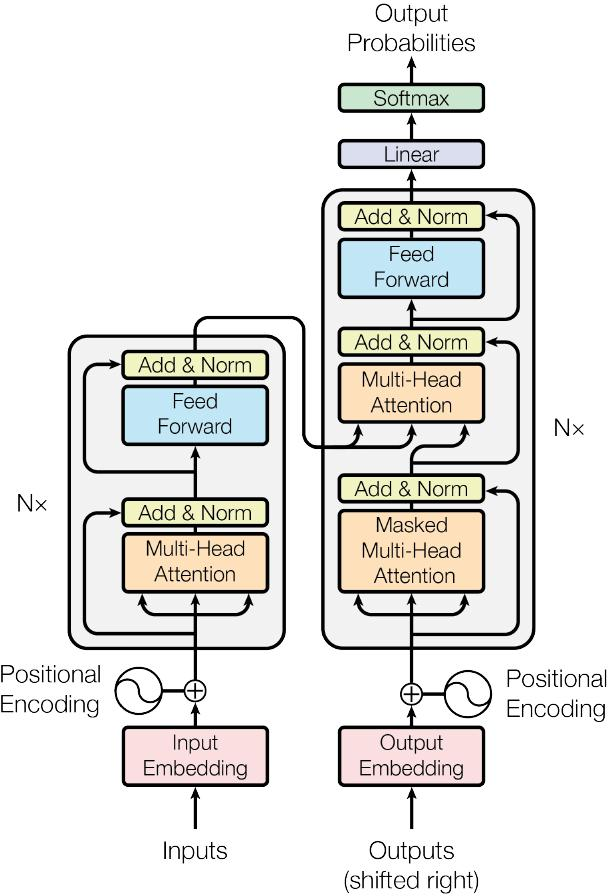

In [39]:
plt_img_base64(retrieved_docs[1])

### Utilities to separate retrieved elements

We need to bin the retrieved doc(s) into the correct parts of the GPT-4o prompt template.

Here we need to have text, table elements as one set of inputs and image elements as the other set of inputs as both require separate prompts in GPT-4o.

In [40]:
import re
import base64

def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None


def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []
    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content.decode('utf-8')
        else:
            doc = doc.decode('utf-8')
        if looks_like_base64(doc) and is_image_data(doc):
            b64_images.append(doc)
        else:
            texts.append(doc)
    return {"images": b64_images, "texts": texts}

In [41]:
# Check retrieval III: get back images and tables also that are relevant to the question.
query = "Explain how positional encoding is implemented in Transformers and why it is necessary."
retrieved_docs = retriever_multi_vector.invoke(query, limit=5)

len(retrieved_docs)

2025-06-05 15:46:54 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


4

In [42]:
retrieved_docs[0]

b'...'

In [43]:
is_image_data(retrieved_docs[0].decode('utf-8'))

True

In [44]:
r = split_image_text_types(retrieved_docs)
r

{'images': ['...'],
 'texts': ['3.3 Position-wise Feed-Forward Networks\n\nIn addition to attention sub-layers, each of the layers in our encoder and decoder contains a fully connected feed-forward network, which is applied to each position separately and identically. This consists of two linear transformations with a ReLU activation in between.\n\nFFN(x) = max(0,xW1 + b1)W2 + b2 (2)\n\nWhile the linear transformations are the same across different positions, they use different parameters from layer to layer. Another way of describing this is as two convolutions with kernel size 1. The dimensionality of input and output is dmodel = 512, and the inner-layer has dimensionality dff = 2048.\n\n3.4 Embeddings and Softmax\n\nSimilarly to other sequence transduction models, we use learned embeddings to convert the input tokens and output tokens to vectors of dimension dmodel. We also use the usual learned linear transfor- mation and softmax function to convert the decoder output to predicted 

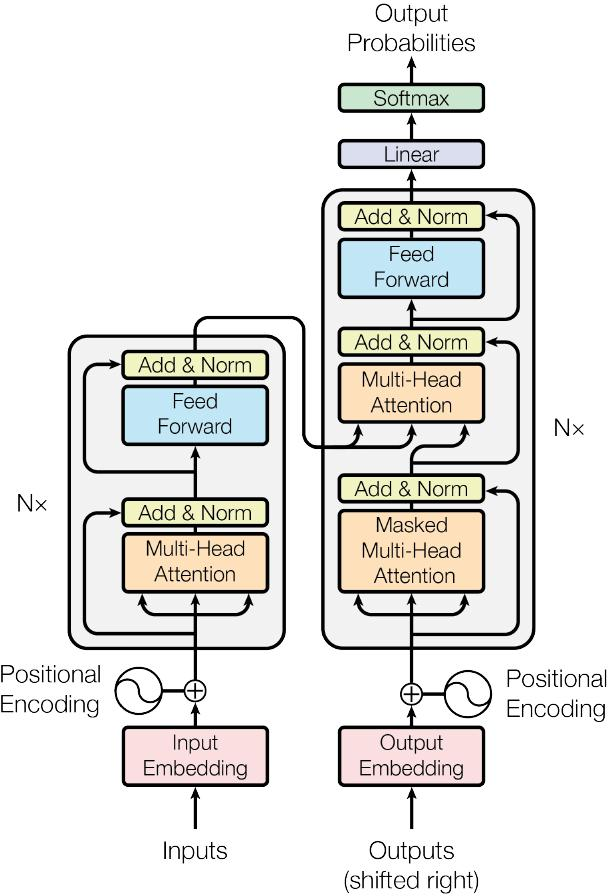

In [45]:
plt_img_base64(r['images'][0])

## Multimodal RAG

### Build End-to-End Multimodal RAG Pipeline

Now let's connect our retriever, prompt instructions and build a multimodal RAG chain

In [46]:
from operator import itemgetter
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.messages import HumanMessage


def multimodal_prompt_function(data_dict):
    """
    Create a multimodal prompt with both text and image context.

    This function formats the provided context from `data_dict`, which contains
    text, tables, and base64-encoded images. It joins the text (with table) portions
    and prepares the image(s) in a base64-encoded format to be included in a message.

    The formatted text and images (context) along with the user question are used to
    construct a prompt for GPT-4o
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text and tables for analysis
    text_message = {
        "type": "text",
        "text": (
            f"""You are an analyst tasked with understanding detailed information and trends
                from text documents, data tables, and charts and graphs in images.
                You will be given context information below which will be a mix of text, tables,
                and images usually of charts or graphs.
                Use this information to provide answers related to the user question.
                Analyze all the context information including tables, text and images to generate the answer.
                Do not make up answers, use the provided context documents below
                and answer the question to the best of your ability.

                User question:
                {data_dict['question']}

                Context documents:
                {formatted_texts}

                Answer:
            """
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]

In [47]:
# Create RAG chain
multimodal_rag = (
        {
            "context": itemgetter('context'),
            "question": itemgetter('input'),
        }
            |
        # RunnableLambda wraps a regular Python function (here: multimodal_prompt_function)
        # and makes it compatible with LangChain's composable Runnable system.
        # It formats the input into a prompt that GPT can understand.
        RunnableLambda(multimodal_prompt_function)
            |
        chatgpt
            |
        StrOutputParser()  # Parses the model output from raw string format
)

# Pass input query to retriever and get context document elements
retrieve_docs = (
                itemgetter('input')
                    |
                retriever_multi_vector  # Fetches relevant documents based on input
                    |
                # This function splits the retrieved documents into text, tables, and images
                # RunnableLambda again allows using plain Python logic within the LangChain pipeline
                RunnableLambda(split_image_text_types)
)

# Below, we chain `.assign` calls. This takes a dict and successively
# adds keys-- "context" and "answer"-- where the value for each key
# is determined by a Runnable (function or chain executing at runtime).
# This helps in also having the retrieved context along with the answer generated by GPT-4o
multimodal_rag_w_sources = (
    RunnablePassthrough
        .assign(context=retrieve_docs)  # Inject retrieved docs under the "context" key
        .assign(answer=multimodal_rag)  # Run multimodal RAG chain to produce final answer
)


In [49]:
def pretty_print_result(data: dict):
    # ANSI escape codes for simple coloring
    COLOR_INPUT = "\033[94m"     # Blue
    COLOR_CONTEXT = "\033[92m"  # Bright Green
    COLOR_ANSWER = "\033[93m"    # Yellow
    RESET = "\033[0m"

    print(f"{COLOR_INPUT}🔹 Input:\n{data.get('input', '')}{RESET}\n")
    
    print(f"{COLOR_ANSWER}💡 Answer:\n{data.get('answer', '')}{RESET}\n")

    print(f"{COLOR_CONTEXT}📘 Context:")
    context = data.get('context', [])
    
    # Print Text Contexts
    text_sources = context.get('texts', [])
    if text_sources:
        print(f"📘 Retrieved Text Contexts:")
        for i, text in enumerate(text_sources, 1):
            print(f"[{i}]\n{text}\n")

    # Print Image Contexts
    img_sources = context.get('images', [])
    if img_sources:
        print(f"🖼️ Retrieved Image Contexts:")
        for i, img in enumerate(img_sources, 1):
            print(f"[{i}]")
            plt_img_base64(img)
            print()
    print(RESET)

In [48]:
# Run RAG chain
query = "Describe the concept of multi-head attention in the Transformer architecture. Why is it beneficial?"
response = multimodal_rag_w_sources.invoke({'input': query})
list(response.keys())

2025-06-05 15:47:34 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:47:51 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


['input', 'context', 'answer']

🔹 Input:
Describe the concept of multi-head attention in the Transformer architecture. Why is it beneficial?

💡 Answer:
Multi-head attention is a key component of the Transformer architecture, which enhances the model's ability to focus on different parts of the input sequence simultaneously. Here's a detailed explanation of the concept and its benefits:

### Concept of Multi-Head Attention

1. **Multiple Attention Heads**: Instead of performing a single attention function, multi-head attention involves multiple attention mechanisms (or "heads") running in parallel. Each head independently projects the queries, keys, and values into different subspaces using learned linear projections.

2. **Parallel Attention**: Each attention head performs the scaled dot-product attention independently on its respective projections. This allows the model to capture different types of relationships and dependencies in the data.

3. **Concatenation and Linear Projection**: The outputs from all the atte

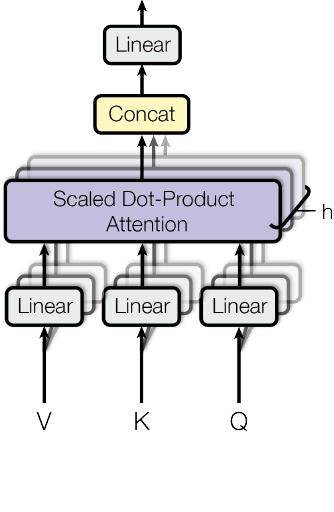

In [50]:
pretty_print_result(response)

## Sample Questions | Test Cases

In [51]:
def query_multimodal_rag(query):
    response = multimodal_rag_w_sources.invoke({'input': query})
    pretty_print_result(response)

In [52]:
query = "What are the main components of a RAG model, and how do they interact?"
query_multimodal_rag(query)

2025-06-05 15:48:23 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:48:31 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


🔹 Input:
What are the main components of a RAG model, and how do they interact?

💡 Answer:
The main components of a Retrieval-Augmented Generation (RAG) model are the retriever and the generator, and they interact in a specific way to produce outputs for knowledge-intensive tasks.

1. **Retriever (pη(z|x))**: This component is responsible for retrieving relevant documents based on the input query. It uses a bi-encoder architecture, where both the document and query are encoded using BERT-based encoders. The retriever calculates the top-K documents with the highest prior probability, which is a Maximum Inner Product Search (MIPS) problem. The retriever is initialized with a pre-trained bi-encoder from DPR (Dense Passage Retrieval) and is designed to retrieve documents that contain answers to specific questions.

2. **Generator (pθ(yi|x,z,y1:i−1))**: The generator produces the output sequence by generating each token based on the context of the previous tokens, the original input, and th

2025-06-05 15:48:31 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:48:34 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


🔹 Input:
What are the two sub-layers in each encoder layer of the Transformer model?

💡 Answer:
The two sub-layers in each encoder layer of the Transformer model are:

1. **Multi-Head Self-Attention Mechanism**
2. **Position-wise Fully Connected Feed-Forward Network**

📘 Context:
📘 Retrieved Text Contexts:
[1]
3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.

2

Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Add & Norm Feed Forward Nx | -+CAgc8 Norm) Add & Norm Masked Multi-Head Multi-Head Attention A

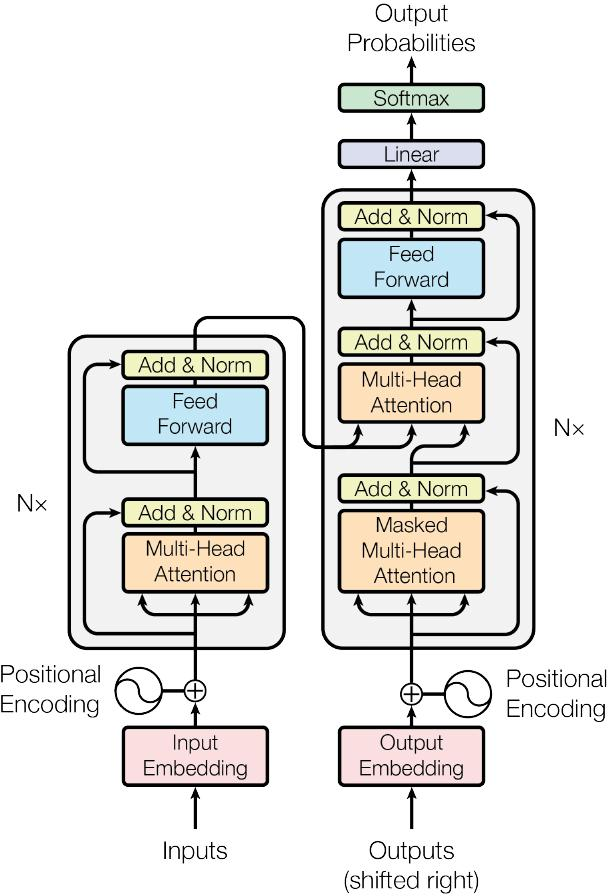

In [53]:
query = "What are the two sub-layers in each encoder layer of the Transformer model?"
query_multimodal_rag(query)

2025-06-05 15:48:35 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:48:42 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


🔹 Input:
Explain how positional encoding is implemented in Transformers and why it is necessary.

💡 Answer:
In Transformers, positional encoding is crucial because the model architecture lacks recurrence and convolution, which are typically used to capture the order of sequences. Without positional encoding, the model would treat input tokens as a bag of words, ignoring their order.

### Implementation of Positional Encoding:

1. **Purpose**: Positional encoding provides information about the position of tokens in a sequence, allowing the model to understand the order.

2. **Method**: The Transformer uses sinusoidal functions to generate positional encodings. These encodings are added to the input embeddings at the bottom of the encoder and decoder stacks.

3. **Formula**:
   - For even indices: \( \text{PE}(pos, 2i) = \sin(pos / 10000^{2i/d_{\text{model}}}) \)
   - For odd indices: \( \text{PE}(pos, 2i+1) = \cos(pos / 10000^{2i/d_{\text{model}}}) \)
   - Here, \( pos \) is the positio

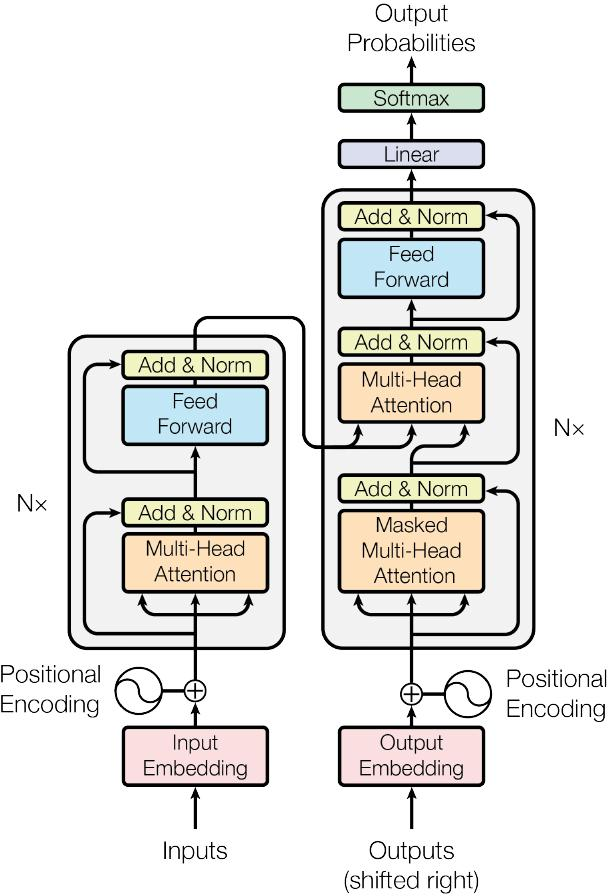

In [54]:
query = "Explain how positional encoding is implemented in Transformers and why it is necessary."
query_multimodal_rag(query)

2025-06-05 15:48:43 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:48:52 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


🔹 Input:
Describe the concept of multi-head attention in the Transformer architecture. Why is it beneficial?

💡 Answer:
Multi-head attention is a key component of the Transformer architecture, which enhances the model's ability to focus on different parts of the input sequence simultaneously. Here's a detailed explanation of the concept and its benefits:

### Concept of Multi-Head Attention

1. **Multiple Attention Heads**: Instead of performing a single attention function, multi-head attention involves multiple attention mechanisms (or "heads") running in parallel. Each head independently projects the queries, keys, and values into different subspaces using learned linear projections.

2. **Parallel Attention**: Each attention head computes the attention function in parallel on these projected versions, resulting in multiple sets of output values.

3. **Concatenation and Projection**: The outputs from all the attention heads are concatenated and then linearly projected to form the fin

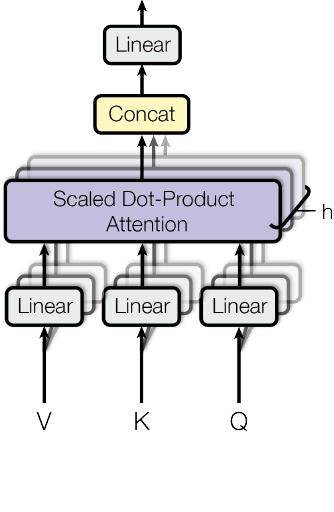

In [55]:
query = "Describe the concept of multi-head attention in the Transformer architecture. Why is it beneficial?"
query_multimodal_rag(query)

In [56]:
query = "What is few-shot learning, and how does GPT-3 implement it during inference?"
query_multimodal_rag(query)

2025-06-05 15:48:53 - INFO    : HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-06-05 15:48:58 - INFO    : HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


🔹 Input:
What is few-shot learning, and how does GPT-3 implement it during inference?

💡 Answer:
Few-shot learning is a method where a model is given a few examples of a task during inference to help it understand and perform the task, without any gradient updates or fine-tuning. In the context of GPT-3, few-shot learning involves providing the model with a natural language task description and a few examples (typically between 10 to 100) of the task as part of its input context. The model then uses these examples to condition its predictions for a new, similar task.

GPT-3 implements few-shot learning by leveraging its large pre-trained model, which has been exposed to a broad distribution of tasks during training. During inference, the model is presented with a few examples of the task (in addition to the task description), and it uses these examples to generate the desired output for a new input. This process does not involve any updates to the model's weights; instead, it relies on